## Supply Chain Analysis

The supply Chain is the network of production and logistics involved in producing and delivering goods to customers. And Supply Chain Analysis means analyzing various components of a Supply Chain to understand how to improve the effectiveness of the Supply Chain to create more value for customers.To analyze a company’s supply chain, we need data on the different stages of the supply chain, like data about sourcing, manufacturing, transportation, inventory management, sales and customer demographics.

Let’s get started with the task of Supply Chain Analysis by importing the necessary Python libraries and the dataset:

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("supply_chain_data.csv")
print(data.head())

  Product type   SKU      Price  Availability  Number of products sold  \
0     haircare  SKU0  69.808006            55                      802   
1     skincare  SKU1  14.843523            95                      736   
2     haircare  SKU2  11.319683            34                        8   
3     skincare  SKU3  61.163343            68                       83   
4     skincare  SKU4   4.805496            26                      871   

   Revenue generated Customer demographics  Stock levels  Lead times  \
0        8661.996792            Non-binary            58           7   
1        7460.900065                Female            53          30   
2        9577.749626               Unknown             1          10   
3        7766.836426            Non-binary            23          13   
4        2686.505152            Non-binary             5           3   

   Order quantities  ...  Location Lead time  Production volumes  \
0                96  ...    Mumbai        29          

Let’s have a look at the descriptive statistics of the dataset:

In [2]:
print(data.describe())

            Price  Availability  Number of products sold  Revenue generated  \
count  100.000000    100.000000               100.000000         100.000000   
mean    49.462461     48.400000               460.990000        5776.048187   
std     31.168193     30.743317               303.780074        2732.841744   
min      1.699976      1.000000                 8.000000        1061.618523   
25%     19.597823     22.750000               184.250000        2812.847151   
50%     51.239831     43.500000               392.500000        6006.352023   
75%     77.198228     75.000000               704.250000        8253.976921   
max     99.171329    100.000000               996.000000        9866.465458   

       Stock levels  Lead times  Order quantities  Shipping times  \
count    100.000000  100.000000        100.000000      100.000000   
mean      47.770000   15.960000         49.220000        5.750000   
std       31.369372    8.785801         26.784429        2.724283   
min        0

Now let’s get started with analyzing the Supply Chain by looking at the relationship between the price of the products and the revenue generated by them:

<Figure size 1000x600 with 0 Axes>

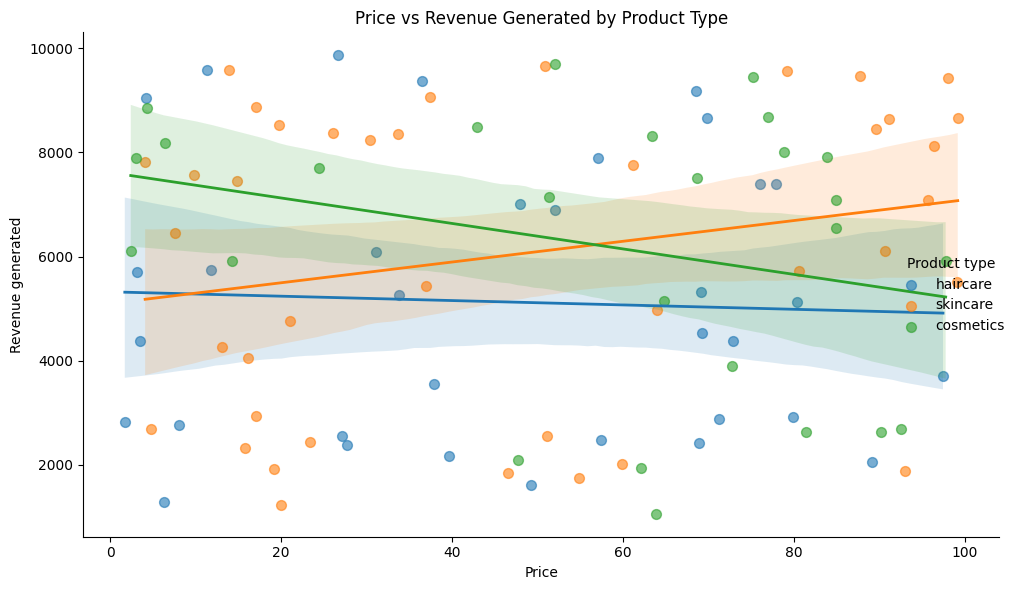

In [3]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=data, 
           x='Price', 
           y='Revenue generated', 
           hue='Product type', 
           scatter_kws={'s': 50, 'alpha': 0.6},
           line_kws={'linewidth': 2}, 
           height=6, 
           aspect=1.5)

plt.title("Price vs Revenue Generated by Product Type")
plt.tight_layout()
plt.show()

Thus, the company derives more revenue from skincare products, and the higher the price of skincare products, the more revenue they generate. Now let’s have a look at the sales by product type:

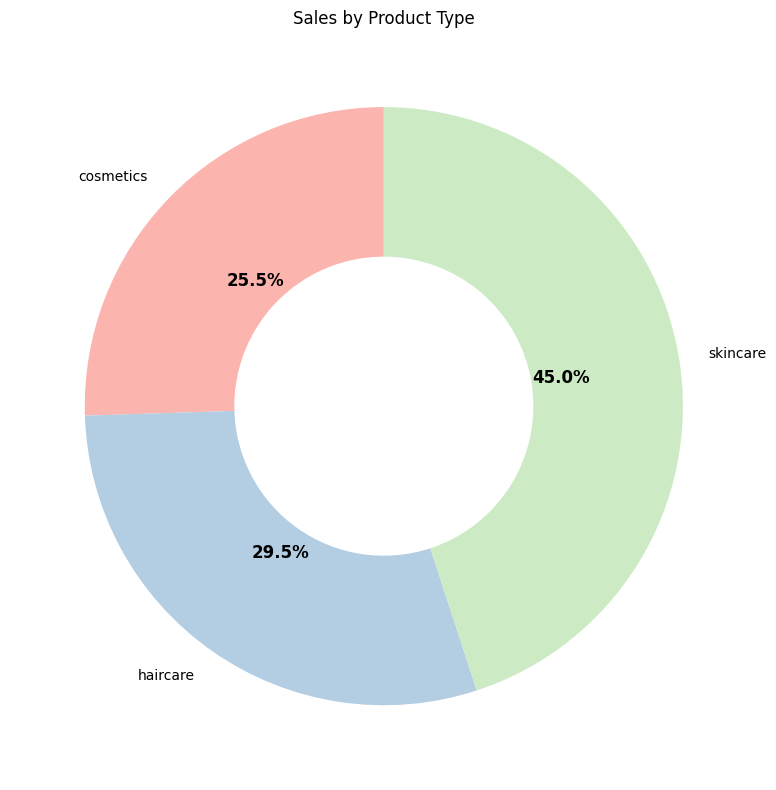

In [4]:
sales_data = data.groupby('Product type')['Number of products sold'].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    sales_data['Number of products sold'],
    labels=sales_data['Product type'],
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Pastel1.colors,
    wedgeprops=dict(width=0.5)  # Creates the "donut" hole
)

# Style
plt.setp(autotexts, size=12, weight="bold", color="black")
ax.set_title('Sales by Product Type')

plt.tight_layout()
plt.show()

So 45% of the business comes from skincare products, 29.5% from haircare, and 25.5% from cosmetics. Now let’s have a look at the total revenue generated from shipping carriers:

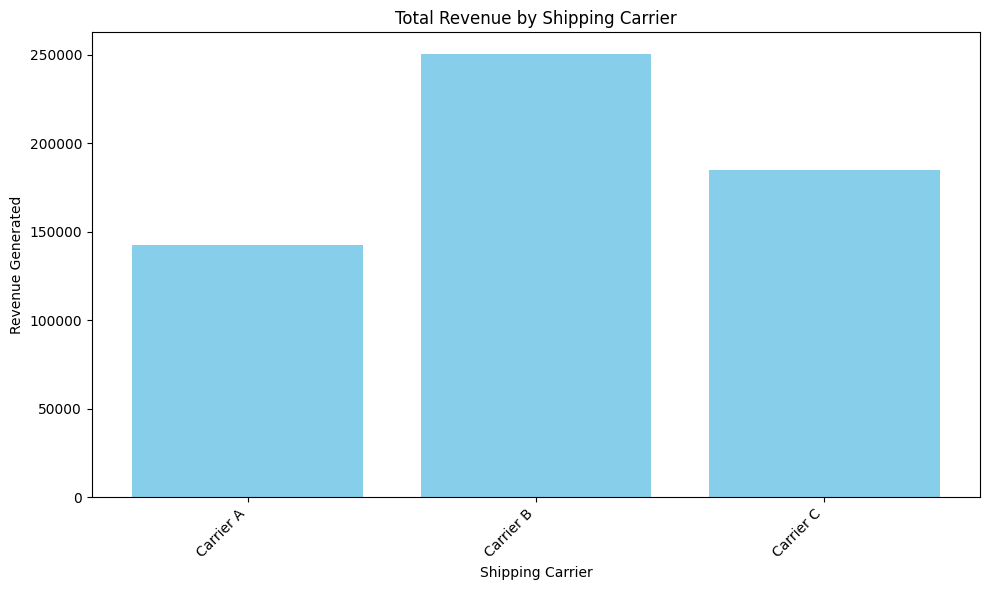

In [5]:
total_revenue = data.groupby('Shipping carriers')['Revenue generated'].sum().reset_index()
plt.figure(figsize=(10, 6))
plt.bar(total_revenue['Shipping carriers'], total_revenue['Revenue generated'], color='skyblue')

# Add labels and title
plt.title('Total Revenue by Shipping Carrier')
plt.xlabel('Shipping Carrier')
plt.ylabel('Revenue Generated')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

So the company is using three carriers for transportation, and Carrier B helps the company in generating more revenue. Now let’s have a look at the Average lead time and Average Manufacturing Costs for all products of the company:

In [8]:
avg_lead_time = data.groupby('Product type')['Lead time'].mean().reset_index()
avg_manufacturing_costs = data.groupby('Product type')['Manufacturing costs'].mean().reset_index()
result = pd.merge(avg_lead_time, avg_manufacturing_costs, on='Product type')
result.rename(columns={'Lead time': 'Average Lead Time', 'Manufacturing costs': 'Average Manufacturing Costs'}, inplace=True)
print(result)

  Product type  Average Lead Time  Average Manufacturing Costs
0    cosmetics          13.538462                    43.052740
1     haircare          18.705882                    48.457993
2     skincare          18.000000                    48.993157


## Analyzing SKUs

There’s a column in the dataset as SKUs. You must have heard it for the very first time. So, SKU stands for Stock Keeping Units. They’re like special codes that help companies keep track of all the different things they have for sale. Imagine you have a large toy store with lots of toys. Each toy is different and has its name and price, but when you want to know how many you have left, you need a way to identify them. So you give each toy a unique code, like a secret number only the store knows. This secret number is called SKU.Now let’s analyze the revenue generated by each SKU:

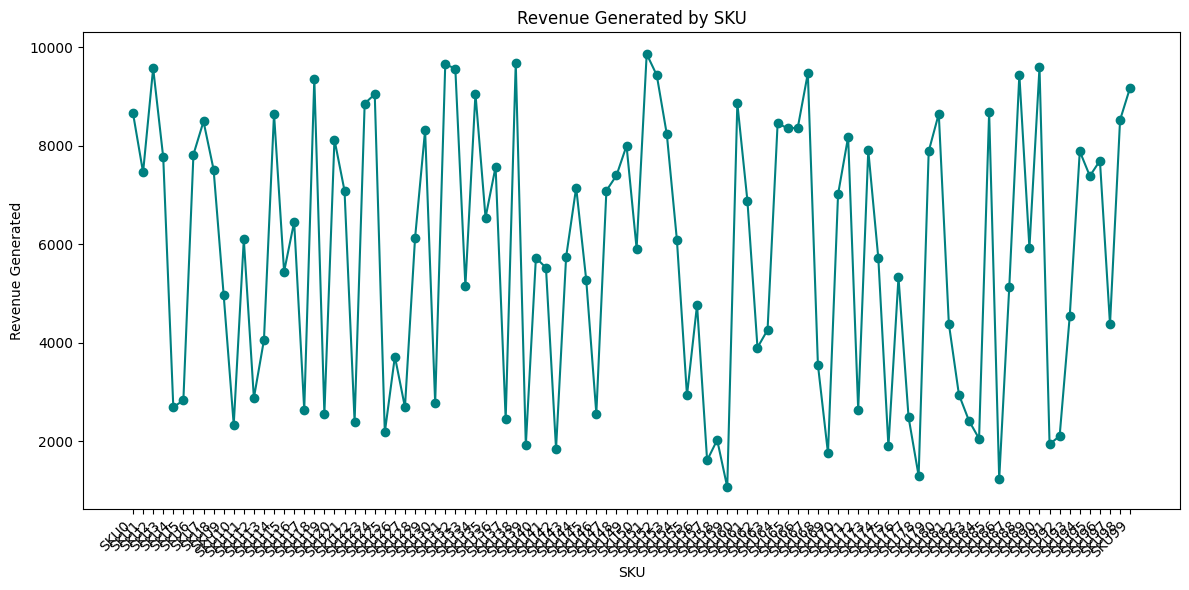

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(data['SKU'], data['Revenue generated'], marker='o', linestyle='-', color='teal')

# Add title and axis labels
plt.title('Revenue Generated by SKU')
plt.xlabel('SKU')
plt.ylabel('Revenue Generated')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

There’s another column in the dataset as Stock levels. Stock levels refer to the number of products a store or business has in its inventory. Now let’s have a look at the stock levels of each SKU:

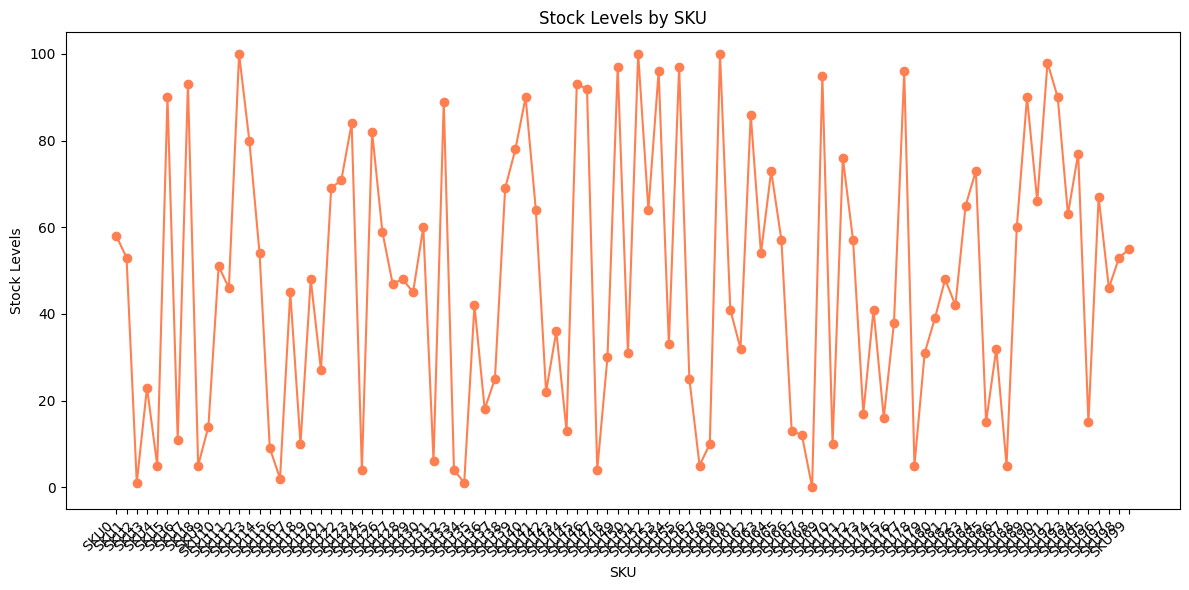

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(data['SKU'], data['Stock levels'], marker='o', linestyle='-', color='coral')

# Add title and axis labels
plt.title('Stock Levels by SKU')
plt.xlabel('SKU')
plt.ylabel('Stock Levels')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Now let’s have a look at the order quantity of each SKU:

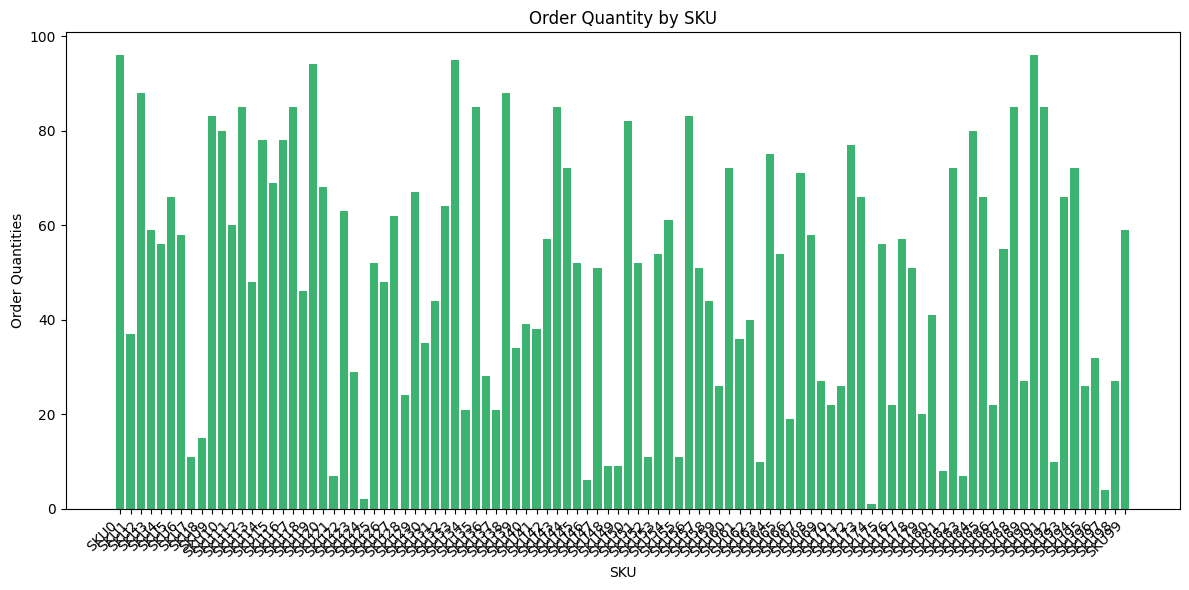

In [8]:
plt.figure(figsize=(12, 6))
plt.bar(data['SKU'], data['Order quantities'], color='mediumseagreen')

# Add title and axis labels
plt.title('Order Quantity by SKU')
plt.xlabel('SKU')
plt.ylabel('Order Quantities')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Cost Analysis

Now let’s analyze the shipping cost of Carriers:

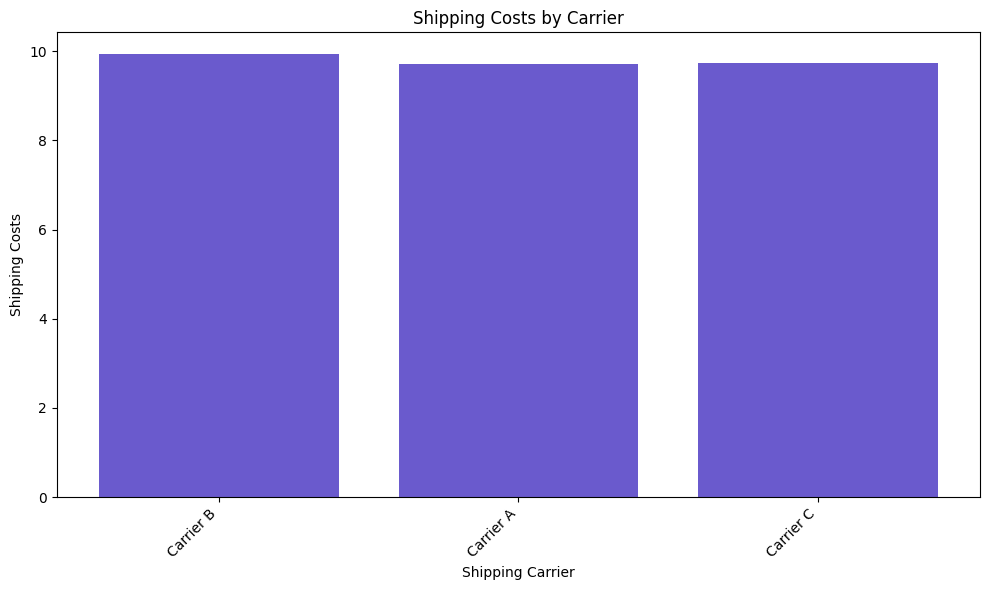

In [9]:
plt.figure(figsize=(10, 6))
plt.bar(data['Shipping carriers'], data['Shipping costs'], color='slateblue')

# Add title and axis labels
plt.title('Shipping Costs by Carrier')
plt.xlabel('Shipping Carrier')
plt.ylabel('Shipping Costs')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In one of the above visualizations, we discovered that Carrier B helps the company in more revenue. It is also the most costly Carrier among the three. Now let’s have a look at the cost distribution by transportation mode:

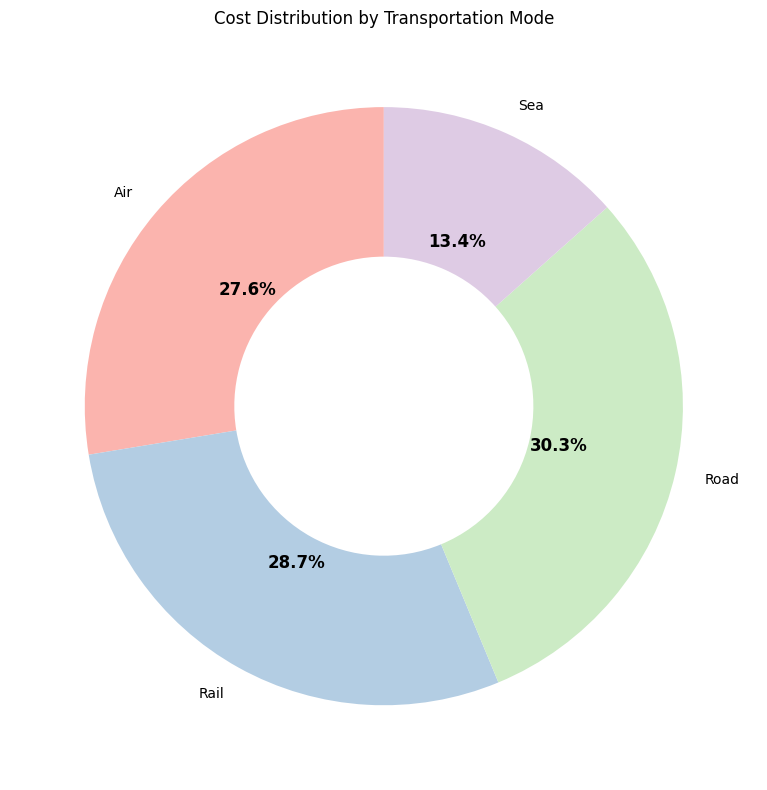

In [11]:
transportation_data = data.groupby('Transportation modes')['Costs'].sum().reset_index()

# Donut pie chart: Cost distribution by transportation mode
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    transportation_data['Costs'],
    labels=transportation_data['Transportation modes'],
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Pastel1.colors,
    wedgeprops=dict(width=0.5)  # Makes it a donut chart
)

# Style
plt.setp(autotexts, size=12, weight="bold", color="black")
ax.set_title('Cost Distribution by Transportation Mode')

plt.tight_layout()
plt.show()

So the company spends more on Road and Rail modes of transportation for the transportation of Goods.

## Analyzing Defect Rate

The defect rate in the supply chain refers to the percentage of products that have something wrong or are found broken after shipping. Let’s have a look at the average defect rate of all product types:

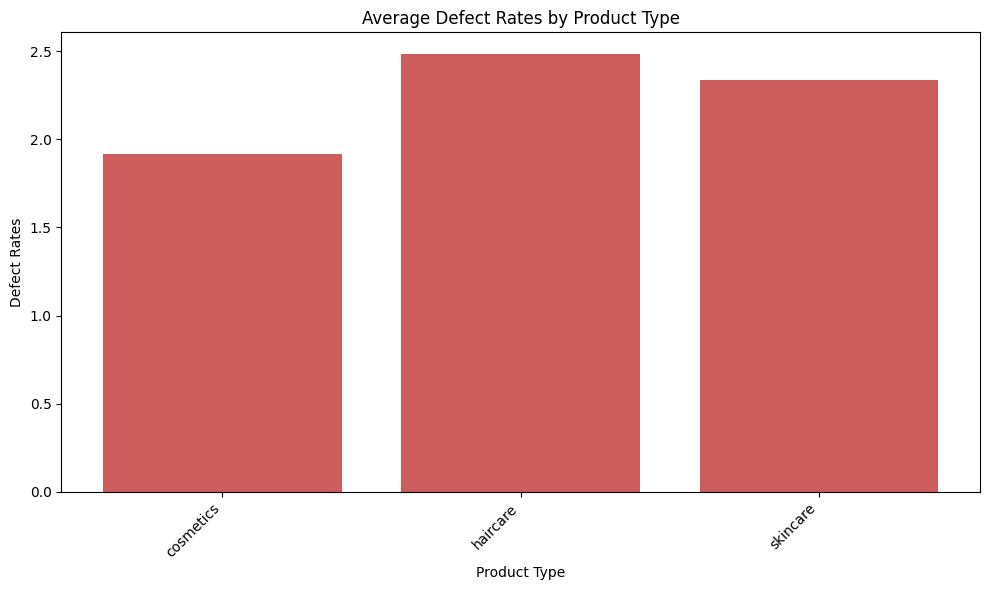

In [12]:
defect_rates_by_product = data.groupby('Product type')['Defect rates'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(defect_rates_by_product['Product type'], defect_rates_by_product['Defect rates'], color='indianred')

# Add title and axis labels
plt.title('Average Defect Rates by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Defect Rates')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

So the defect rate of haircare products is higher. Now let’s have a look at the defect rates by mode of transportation:

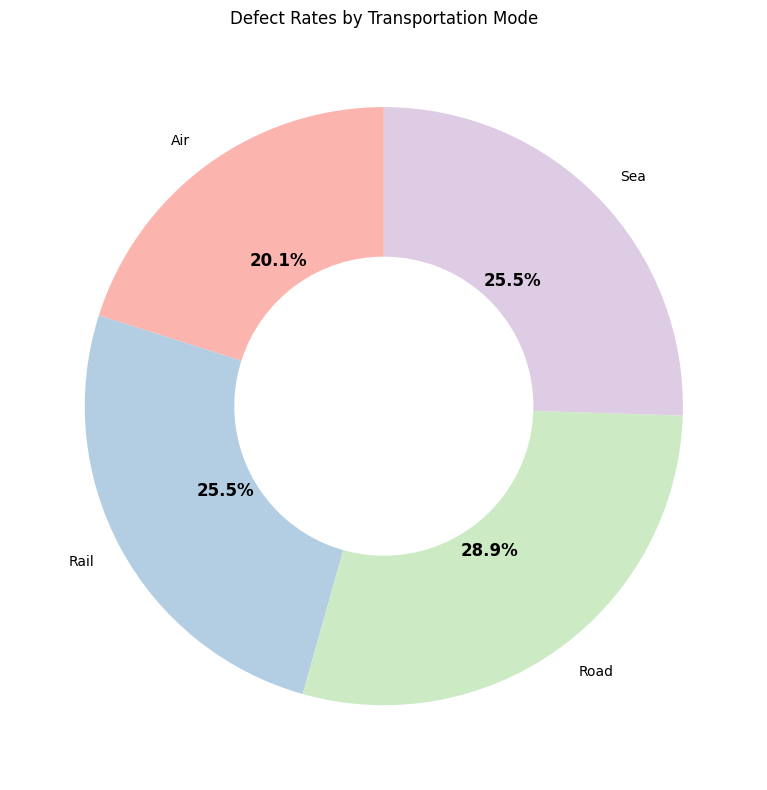

In [13]:
pivot_table = pd.pivot_table(data, values='Defect rates', 
                             index=['Transportation modes'], 
                             aggfunc='mean')

# Donut pie chart using matplotlib
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    pivot_table['Defect rates'],
    labels=pivot_table.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Pastel1.colors,
    wedgeprops=dict(width=0.5)  # Creates donut hole
)

# Styling
plt.setp(autotexts, size=12, weight="bold", color="black")
ax.set_title('Defect Rates by Transportation Mode')

plt.tight_layout()
plt.show()

Road transportation results in a higher defect rate, and Air transportation has the lowest defect rate.